# LSTM Latent Visualization Demo (etth1)

Notebook nay chay model **lstm** tren dataset **etth1**, sau do trich latent embedding va ve 2D/3D de so sanh voi TimesFM.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

PROJECT_ROOT


PosixPath('/Users/hieuduc/Downloads/AAAI')

In [2]:
import numpy as np
import torch
import torch.nn as nn
import plotly.graph_objects as go
import matplotlib.pyplot as plt

from src.data.datasets import load_dataset
from src.latents.visualize import project_umap, project_umap_3d
from src.models.baselines import TransformerRegressor, LSTMRegressor, TCNRegressor


def resolve_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

device = resolve_device()
print("device =", device)


device = mps


In [3]:
# ==== Config ====
DATASET = "etth1"
MODEL_NAME = "lstm"   # transformer | lstm | tcn
CONTEXT_LENGTH = 64
HORIZON = 24
MAX_WINDOWS = 1500
TRAIN_RATIO = 0.8
EPOCHS = 8
BATCH_SIZE = 256
LR = 1e-3
SEED = 42

# plot readability
PLOT_2D_MAX_POINTS = 1000
PLOT_3D_MAX_POINTS = 200
PLOT_3D_TRAJ_POINTS = 60

np.random.seed(SEED)
torch.manual_seed(SEED)


In [4]:
def build_windows(series, context_length=64, horizon=24, max_windows=1500):
    X, y = [], []
    for i in range(context_length, len(series)-horizon+1):
        X.append(series[i-context_length:i])
        y.append(series[i+horizon-1])
    X = np.asarray(X, dtype=np.float32)
    y = np.asarray(y, dtype=np.float32)

    if len(X) > max_windows:
        idx = np.linspace(0, len(X)-1, num=max_windows, dtype=int)
        X = X[idx]
        y = y[idx]

    # normalize by train stats later
    return X, y


def make_model(model_name: str):
    m = model_name.lower()
    if m == "transformer":
        return TransformerRegressor(d_model=128, nhead=8, num_layers=2)
    if m == "lstm":
        return LSTMRegressor(hidden_size=128, num_layers=2)
    if m == "tcn":
        return TCNRegressor(channels=128, kernel_size=3, num_blocks=3)
    raise ValueError(f"Unsupported MODEL_NAME: {model_name}")


def extract_latent(model, xb, model_name: str):
    m = model_name.lower()
    if m == "transformer":
        z = model.proj(xb)
        z = model.encoder(z)
        return z.mean(dim=1)
    if m == "lstm":
        z, _ = model.lstm(xb)
        return z[:, -1, :]
    if m == "tcn":
        z = model.net(xb.transpose(1, 2))
        return z[:, :, -1]
    raise ValueError(model_name)


In [5]:
ds = load_dataset(DATASET)
series = ds.frame[ds.target_col].astype(float).to_numpy()
X, y = build_windows(series, context_length=CONTEXT_LENGTH, horizon=HORIZON, max_windows=MAX_WINDOWS)

split = int(len(X) * TRAIN_RATIO)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

x_mean, x_std = X_train.mean(), X_train.std() + 1e-6
y_mean, y_std = y_train.mean(), y_train.std() + 1e-6

X_train = (X_train - x_mean) / x_std
X_test = (X_test - x_mean) / x_std
y_train_n = (y_train - y_mean) / y_std

print("dataset:", DATASET)
print("train/test:", X_train.shape, X_test.shape)


dataset: etth1
train/test: (1200, 64) (300, 64)


In [6]:
model = make_model(MODEL_NAME).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=LR)
loss_fn = nn.MSELoss()

train_x = torch.from_numpy(X_train[:, :, None]).to(device)
train_y = torch.from_numpy(y_train_n[:, None]).to(device)

dataset = torch.utils.data.TensorDataset(train_x, train_y)
loader = torch.utils.data.DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

model.train()
for ep in range(1, EPOCHS + 1):
    losses = []
    for xb, yb in loader:
        opt.zero_grad()
        pred = model(xb)
        loss = loss_fn(pred, yb)
        loss.backward()
        opt.step()
        losses.append(float(loss.item()))
    if ep == 1 or ep == EPOCHS or ep % 2 == 0:
        print(f"epoch {ep}/{EPOCHS} loss={np.mean(losses):.6f}")


epoch 1/8 loss=0.564611
epoch 2/8 loss=0.235008
epoch 4/8 loss=0.178617
epoch 6/8 loss=0.155613
epoch 8/8 loss=0.150517


In [7]:
model.eval()
with torch.no_grad():
    test_x_t = torch.from_numpy(X_test[:, :, None]).to(device)
    lat = extract_latent(model, test_x_t, MODEL_NAME).detach().float().cpu().numpy()

time_idx = np.arange(len(lat), dtype=float)
print("latent shape:", lat.shape)


latent shape: (300, 128)


/Users/hieuduc/Downloads/AAAI/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


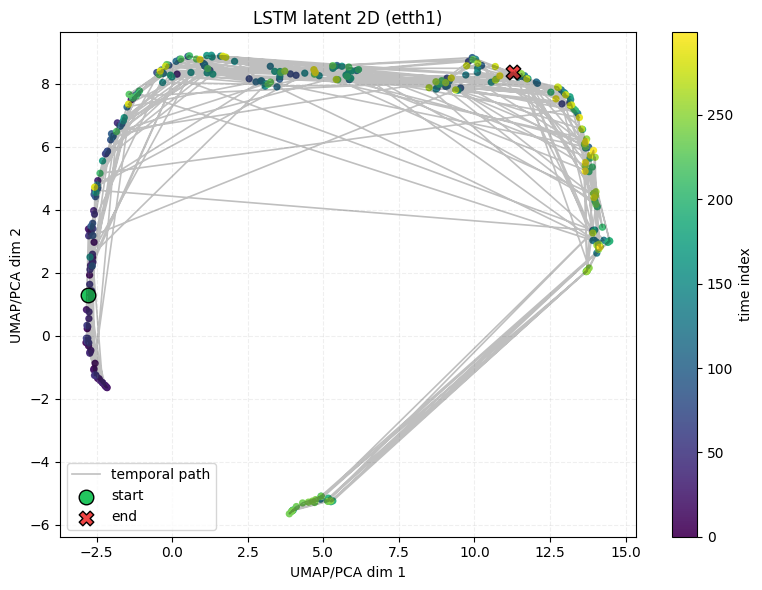

In [8]:
coords2 = project_umap(lat, random_state=SEED)

if len(coords2) > PLOT_2D_MAX_POINTS:
    idx = np.linspace(0, len(coords2)-1, PLOT_2D_MAX_POINTS, dtype=int)
    c2 = coords2[idx]
    t2 = time_idx[idx]
else:
    c2 = coords2
    t2 = time_idx

traj_n = min(len(c2), 300)
traj_idx = np.linspace(0, len(c2)-1, max(2, traj_n), dtype=int)

plt.figure(figsize=(8, 6))
sc = plt.scatter(c2[:, 0], c2[:, 1], c=t2, cmap="viridis", s=18, alpha=0.9)
plt.plot(c2[traj_idx, 0], c2[traj_idx, 1], c="black", alpha=0.25, lw=1.2, label="temporal path")
plt.scatter(c2[0, 0], c2[0, 1], c="#22c55e", s=110, marker="o", edgecolors="black", label="start")
plt.scatter(c2[-1, 0], c2[-1, 1], c="#ef4444", s=110, marker="X", edgecolors="black", label="end")
plt.colorbar(sc, label="time index")
plt.title(f"{MODEL_NAME.upper()} latent 2D ({DATASET})")
plt.xlabel("UMAP/PCA dim 1")
plt.ylabel("UMAP/PCA dim 2")
plt.grid(alpha=0.2, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()


In [9]:
coords3 = project_umap_3d(lat, random_state=SEED)

if len(coords3) > PLOT_3D_MAX_POINTS:
    idx = np.linspace(0, len(coords3)-1, PLOT_3D_MAX_POINTS, dtype=int)
    c3 = coords3[idx]
    t3 = time_idx[idx]
else:
    c3 = coords3
    t3 = time_idx

traj_n = min(len(coords3), PLOT_3D_TRAJ_POINTS)
traj_idx = np.linspace(0, len(coords3)-1, max(2, traj_n), dtype=int)
ct = coords3[traj_idx]

fig = go.Figure(data=[
    go.Scatter3d(
        x=ct[:,0], y=ct[:,1], z=ct[:,2], mode="lines",
        name="temporal path", line=dict(color="#111827", width=4),
    ),
    go.Scatter3d(
        x=c3[:,0], y=c3[:,1], z=c3[:,2], mode="markers", name="windows",
        marker=dict(size=5, color=t3, colorscale="Viridis", opacity=0.9,
                    showscale=True, colorbar=dict(title="time index", x=1.02, y=0.5, len=0.72, thickness=16)),
        hovertemplate="t=%{marker.color:.0f}<br>x=%{x:.3f}<br>y=%{y:.3f}<br>z=%{z:.3f}<extra></extra>",
    ),
    go.Scatter3d(x=[c3[0,0]], y=[c3[0,1]], z=[c3[0,2]], mode="markers", name="start", marker=dict(size=8, color="#22c55e"), showlegend=False),
    go.Scatter3d(x=[c3[-1,0]], y=[c3[-1,1]], z=[c3[-1,2]], mode="markers", name="end", marker=dict(size=8, color="#ef4444", symbol="diamond"), showlegend=False),
])

fig.update_layout(
    template="plotly_white",
    title=f"{MODEL_NAME.upper()} latent 3D ({DATASET})",
    scene=dict(aspectmode="data", xaxis_title="dim 1", yaxis_title="dim 2", zaxis_title="dim 3"),
    margin=dict(l=20, r=160, t=110, b=20),
    legend=dict(orientation="h", yanchor="bottom", y=1.04, xanchor="left", x=0.0),
    width=1300,
    height=700,
)
fig.show()


/Users/hieuduc/Downloads/AAAI/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [10]:
# Save HTML for browser viewing
out_dir = PROJECT_ROOT / "outputs" / "figures"
out_dir.mkdir(parents=True, exist_ok=True)
html_path = out_dir / f"figure_{MODEL_NAME}_3d_{DATASET}.html"
fig.write_html(str(html_path), include_plotlyjs=True, full_html=True)
html_path


PosixPath('/Users/hieuduc/Downloads/AAAI/outputs/figures/figure_lstm_3d_etth1.html')